# EBM1DLat — Diffusive Latitudinal Energy Balance Model


## Overview

`EBM1DLat` resolves a zonal-mean temperature profile T(φ) across a latitude grid, evolving each grid point under absorbed solar radiation, a linear (Budyko) OLR, and meridional heat diffusion:

$$
C \frac{\partial T}{\partial t} = S(x)(1 - \alpha(T)) - \bigl[(A - F_{\mathrm{CO_2}}) + B\,T\bigr] + D\,\nabla^2 T
$$

where $x = \sin\varphi$. Temperature is in **°C** throughout.

### Key differences from `EBM0D`

| | `EBM0D` | `EBM1DLat` |
|--|---------|------------|
| State | scalar T (K) | array T(φ) (°C) |
| OLR | Stefan-Boltzmann (swappable via `param_values`) | Budyko linear: $(A - F_{\mathrm{CO_2}}) + B\,T$ (override by subclassing) |
| Albedo | swappable via `param_values['albedo']` | array ice-line step function (override `calc_albedo` by subclassing or `set_function`) |
| Solar input | `S0` parameter + `register_forcing` | `S0` parameter + `register_forcing` |
| Diagnostics | accumulated step-by-step in `dydt` | derived from full trajectory after solve (`uses_post_history = True`) |

### Parameters

| Name | Description | Default |
|------|-------------|---------|
| `S0` | Solar constant (W m⁻²) | 1365.0 |
| `C` | Heat capacity (W yr m⁻² K⁻¹) | 10.0 |
| `D` | Meridional diffusion coefficient | 0.55 |
| `A` | Budyko OLR intercept (W m⁻²) | 210.0 |
| `B` | Budyko OLR slope (W m⁻² °C⁻¹) | 2.0 |
| `CO2_forcing` | Radiative forcing from CO₂ (W m⁻²); subtracts from `A`, warming the climate | 0.0 |
| `grid_n` | Number of latitude grid points from −90° to 90° (≥ 3) | 50 |

All parameters are in `param_values` and accept a `float`, callable, or `pb.core.Forcing`.

### Albedo scheme

The built-in `calc_albedo` applies a linear transition at each grid point:

- T < −10 °C → α = 0.6 (ice-covered)
- T > 0 °C → α = 0.3 (ice-free)
- linear blend in between

To replace this scheme, use `set_function('calc_albedo', ...)` on a single instance (see below), or subclass `EBM1DLat` and override `calc_albedo(self, T, t)`. The module also provides `albedo_func1D` — a Legendre polynomial variant — as a ready-made alternative.



## Basic run

The initial condition `y0` can be a **scalar** (broadcast to all grid points) or an array of length `grid_n`. The model has **two stable equilibria** depending on initial conditions: a warm state and a snowball state. Starting from 15 °C gives the warm branch.

A note on `D`: the default `D=0.55` transports enough heat poleward that polar temperatures settle just above −10 °C from a warm start, leaving the model technically ice-free. Using `D=0.35` gives a realistic mid-latitude ice line (~52°) from the same warm start.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import paleobeasts as pb
from paleobeasts.signal_models.ebm import EBM1DLat

model = EBM1DLat(S0=1365.0, grid_n=50, D=0.35)
output = model.integrate(t_span=(0, 2000), y0=[15.0], method='RK45')

State variables are named `T_0` through `T_{grid_n-1}`. The latitude grid is on `model.phi`.

In [46]:
grid_n = model.grid_n
phi    = model.phi   # degrees, shape (grid_n,)

T_final  = np.array([output.state_variables[f'T_{i}'][-1] for i in range(grid_n)])
albedo_final = model.calc_albedo(T_final, t=output.time[-1])
olr_final = model.calc_OLR(T_final, t=output.time[-1])
Tglobal  = output.diagnostic_variables['Tglobal']
ice_line = output.diagnostic_variables['ice_line_lat']
time     = output.time

print(f"Equilibrium Tglobal:  {Tglobal[-1]:.2f} °C")
print(f"Equilibrium ice line: {ice_line[-1]:.1f}°")

Equilibrium Tglobal:  5.07 °C
Equilibrium ice line: 52.3°


### Latitude profile: T, albedo, and OLR

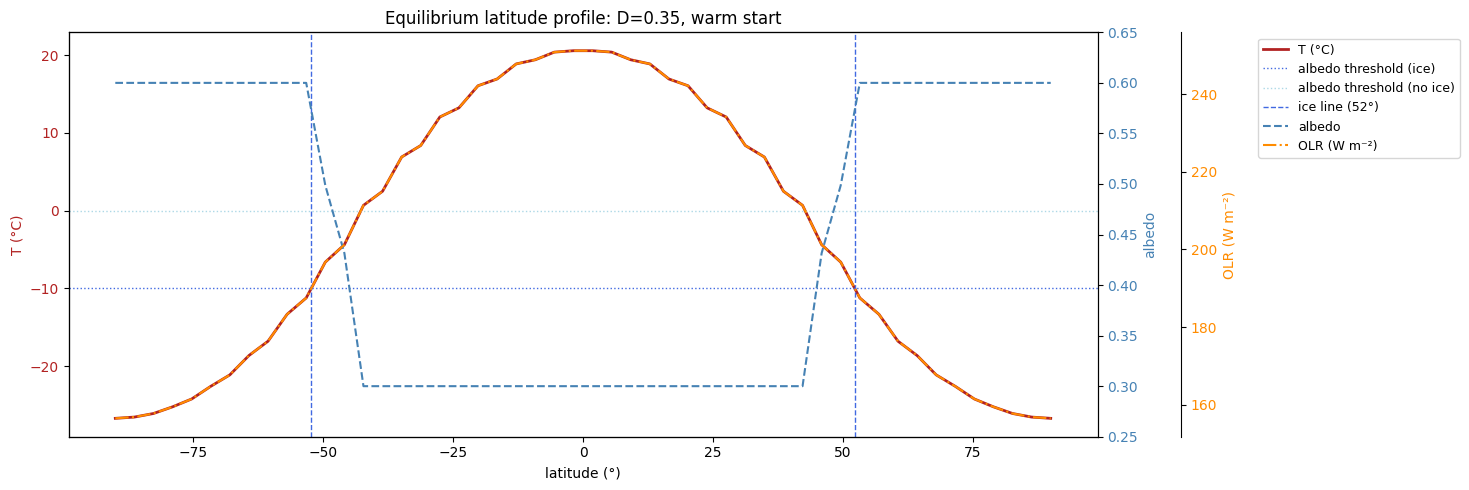

In [47]:
fig, ax1 = plt.subplots(figsize=(15, 5))

# Temperature — left axis
ax1.plot(phi, T_final, color='firebrick', lw=2, label='T (°C)')
ax1.axhline(-10, color='royalblue', ls=':', lw=1, label='albedo threshold (ice)')
ax1.axhline(  0, color='lightblue', ls=':', lw=1, label='albedo threshold (no ice)')
ax1.set_xlabel('latitude (°)')
ax1.set_ylabel('T (°C)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax1.axvline(ice_line[-1], color='royalblue', ls='--', lw=1, label=f'ice line ({ice_line[-1]:.0f}°)')
ax1.axvline(-ice_line[-1], color='royalblue', ls='--', lw=1, label='')

# Albedo — right axis 1
ax2 = ax1.twinx()
ax2.plot(phi, albedo_final, color='steelblue', lw=1.5, ls='--', label='albedo')
ax2.set_ylabel('albedo', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_ylim(0.25, 0.65)

# OLR — right axis 2 (offset)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(phi, olr_final, color='darkorange', lw=1.5, ls='-.', label='OLR (W m⁻²)')
ax3.set_ylabel('OLR (W m⁻²)', color='darkorange')
ax3.tick_params(axis='y', labelcolor='darkorange')

# Combined legend
lines, labels = [], []
for l in (ax1.get_lines() + ax2.get_lines() + ax3.get_lines()):
    label = l.get_label()
    if 'child' not in l.get_label():
        lines.append(l)
        labels.append(label)

ax1.legend(lines, labels, loc='upper left', fontsize=9, bbox_to_anchor = (1.15,1))

ax1.set_title('Equilibrium latitude profile: D=0.35, warm start')
plt.tight_layout()
plt.show()

**Figure.** Equilibrium zonal-mean temperature profile (left axis, red) with albedo and OLR overlaid. Temperature decreases poleward; the ice line (dashed vertical) marks the latitude where T crosses the freezing threshold. Albedo jumps from ~0.3 (ice-free) to ~0.6 (ice-covered) at the ice line. OLR mirrors the temperature pattern — lower in the cold polar regions.

### Time series of global diagnostics

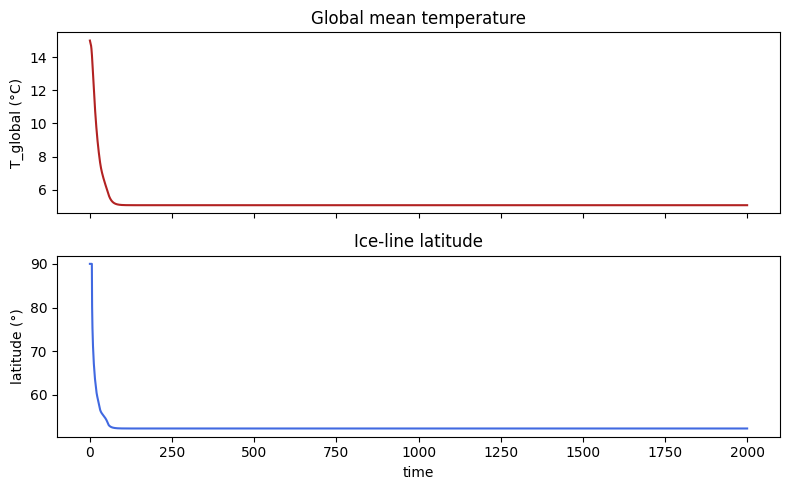

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(time, Tglobal, color='firebrick')
axes[0].set_ylabel('T_global (°C)'); axes[0].set_title('Global mean temperature')

axes[1].plot(time, ice_line, color='royalblue')
axes[1].set_ylabel('latitude (°)'); axes[1].set_xlabel('time')
axes[1].set_title('Ice-line latitude')
plt.tight_layout(); plt.show()

**Figure.** Top: global mean temperature relaxes to equilibrium from the uniform 15 °C start. Bottom: ice-line latitude contracts poleward from the Equator as the model warms. The ice line stabilises once the temperature gradient is in balance with the diffusion — a partial ice cover is the model's stable attractor for these parameters.

## Changing the albedo function

Use `set_function('calc_albedo', fn)` to replace the albedo scheme on a single instance without subclassing. The replacement must have signature `(self, T, t)` (bound method) or `(T, t)` (unbound); the `bind` parameter is inferred from whether the first argument is named `self` or `model`.

Here a sharper transition that switches fully to ice-covered below −5 °C and fully ice-free above 5 °C. With `D=0.35` this produces a stronger ice-albedo feedback — the model collapses to a snowball state, with no stable partial ice line. This is physically meaningful: tighter albedo transitions reduce the range of stable partial-ice states.

In [49]:
def sharper_albedo(self, T, t):
    """Sharper ice-line: transition between −5 °C and +5 °C."""
    temperature = np.asarray(T, dtype=float)
    albedo = np.empty_like(temperature)
    cold = temperature < -5.0
    warm = temperature >  5.0
    transition = (~cold) & (~warm)
    albedo[cold] = 0.6
    albedo[warm] = 0.3
    albedo[transition] = 0.6 - 0.3 * ((temperature[transition] + 5.0) / 10.0)
    return albedo

model_sharp = EBM1DLat(S0=1365.0, grid_n=50, D=0.35)
model_sharp.set_function('calc_albedo', sharper_albedo)
out_sharp = model_sharp.integrate(t_span=(0, 2000), y0=[15.0], method='RK45')

T_sharp = np.array([out_sharp.state_variables[f'T_{i}'][-1] for i in range(grid_n)])
alb_sharp = model_sharp.calc_albedo(T_sharp, t=out_sharp.time[-1])
il_sharp = out_sharp.diagnostic_variables['ice_line_lat'][-1]
print(f"Default albedo: ice line = {ice_line[-1]:.0f}°")
print(f"Sharper albedo: ice line = {il_sharp:.0f}° (snowball)")

Default albedo: ice line = 52°
Sharper albedo: ice line = 0° (snowball)


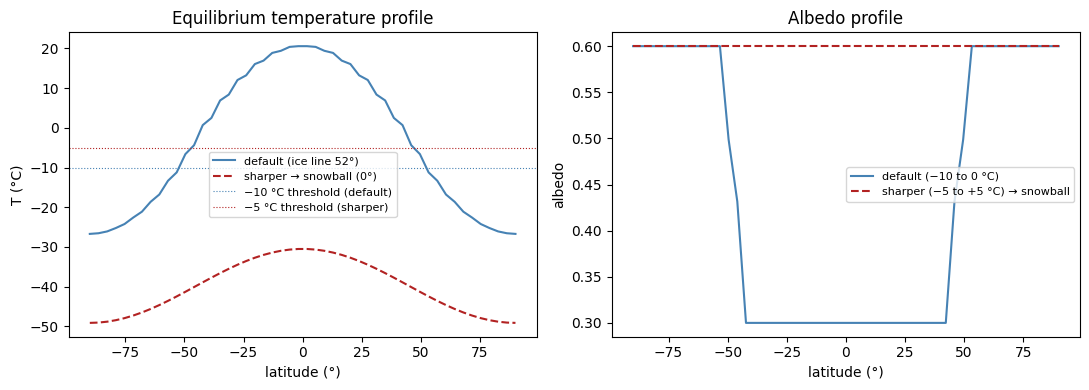

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(phi, T_final,  color='steelblue', label=f'default (ice line {ice_line[-1]:.0f}°)')
axes[0].plot(phi, T_sharp,  color='firebrick', ls='--', label=f'sharper → snowball ({il_sharp:.0f}°)')
axes[0].axhline(-10, color='steelblue', ls=':', lw=0.8, label='−10 °C threshold (default)')
axes[0].axhline( -5, color='firebrick', ls=':', lw=0.8, label='−5 °C threshold (sharper)')
axes[0].set_xlabel('latitude (°)'); axes[0].set_ylabel('T (°C)')
axes[0].set_title('Equilibrium temperature profile'); axes[0].legend(fontsize=8)

axes[1].plot(phi, albedo_final, color='steelblue', label='default (−10 to 0 °C)')
axes[1].plot(phi, alb_sharp,   color='firebrick', ls='--', label='sharper (−5 to +5 °C) → snowball')
axes[1].set_xlabel('latitude (°)'); axes[1].set_ylabel('albedo')
axes[1].set_title('Albedo profile'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Figure.** Left: temperature profiles for the default and sharper albedo schemes. The sharper transition (ice line at −5 °C rather than −10 °C) pushes more of the planet into the high-albedo state, cooling the tropics and driving the model to a snowball. Right: ice-line latitude over time — the sharper scheme collapses to 0° (fully glaciated) within a few hundred years, while the default stabilises at ~65°.

## Forcing via `CO2_forcing`

`CO2_forcing` is the natural way to add a radiative perturbation to this model — it subtracts from the Budyko OLR intercept `A`, warming the climate. Attach it with `register_forcing` after construction.

`pb.core.Forcing` accepts a callable, an array with a time axis, or composable `Hold`/`Ramp`/`Harmonic` elements:

In [51]:
co2_seq = pb.core.Forcing.from_sequence([
    pb.core.Hold(duration=500,  value=0.0),
    pb.core.Ramp(duration=500, y0=0.0, yf=4.0),
    pb.core.Hold(duration=1000, value=4.0),
])

Always plot the forcing before running, so the signal is explicit:

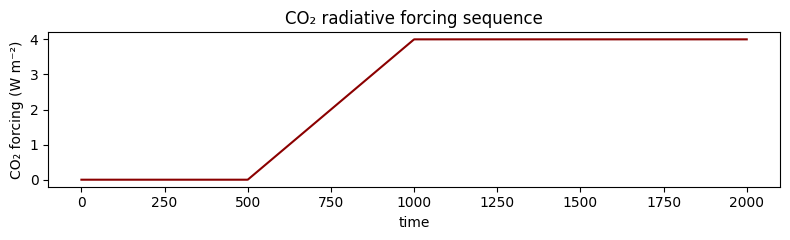

In [52]:
t_plot = np.linspace(0, 2000, 1000)
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t_plot, [co2_seq.get_forcing(t) for t in t_plot], color='darkred')
ax.set_xlabel('time'); ax.set_ylabel('CO₂ forcing (W m⁻²)')
ax.set_title('CO₂ radiative forcing sequence')
plt.tight_layout(); plt.show()

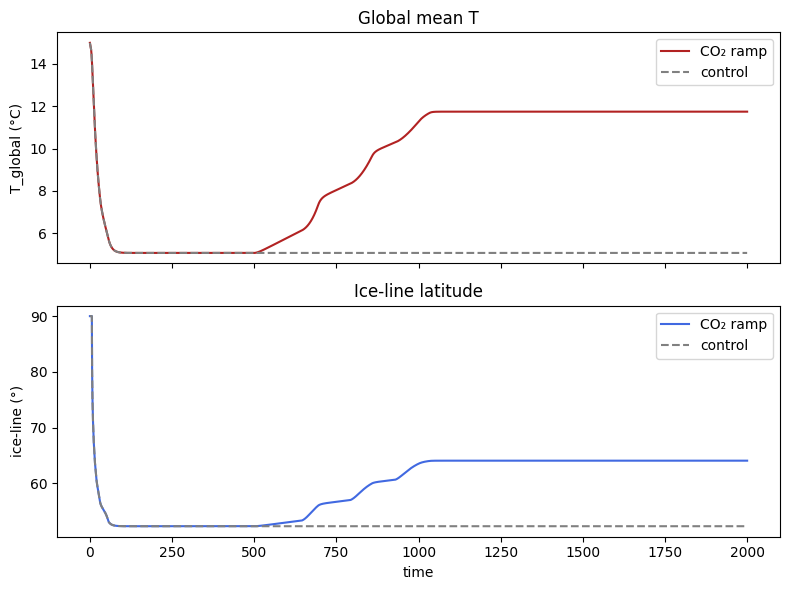

In [53]:
model_co2 = EBM1DLat(S0=1365.0, grid_n=50, D=0.35)
model_co2.register_forcing('CO2_forcing', co2_seq)
out_co2 = model_co2.integrate(t_span=(0, 2000), y0=[15.0], method='RK45')

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(out_co2.time, out_co2.diagnostic_variables['Tglobal'],
             color='firebrick', label='CO₂ ramp')
axes[0].plot(output.time, Tglobal, color='gray', ls='--', label='control')
axes[0].set_ylabel('T_global (°C)'); axes[0].legend(); axes[0].set_title('Global mean T')

axes[1].plot(out_co2.time, out_co2.diagnostic_variables['ice_line_lat'],
             color='royalblue', label='CO₂ ramp')
axes[1].plot(output.time, ice_line, color='gray', ls='--', label='control')
axes[1].set_ylabel('ice-line (°)'); axes[1].set_xlabel('time'); axes[1].legend()
axes[1].set_title('Ice-line latitude')

plt.tight_layout(); plt.show()

**Figure.** Top: global mean temperature under CO₂ ramp-up and ramp-down (solid) vs control (dashed). Warming during the forcing phase is asymmetric with recovery — the ice line retreats quickly as $T$ rises but returns more slowly, reflecting the albedo feedback: a smaller ice cap absorbs more solar radiation, partially offsetting the post-forcing cooling. Bottom: CO₂ forcing sequence for reference.

## Time-evolving parameters

Any `param_values` entry can be a callable with signature `(t)`, `(t, state)`, or `(t, state, model)`. Here `D` increases over time, representing a gradually strengthening poleward heat transport:

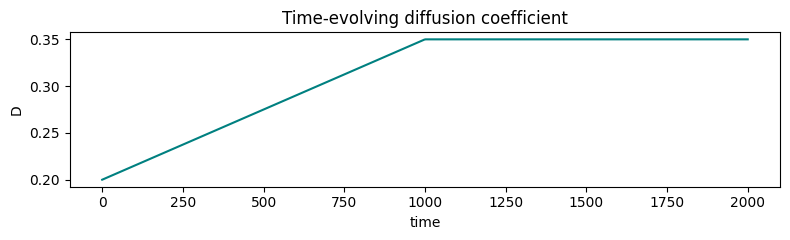

In [54]:
def D_ramp(t):
    return 0.20 + 0.15 * np.clip(t / 1000.0, 0.0, 1.0)

t_plot = np.linspace(0, 2000, 500)
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t_plot, [D_ramp(t) for t in t_plot], color='teal')
ax.set_xlabel('time'); ax.set_ylabel('D'); ax.set_title('Time-evolving diffusion coefficient')
plt.tight_layout(); plt.show()

**Figure.** The diffusion coefficient ramp: $D$ increases linearly from 0.20 to 0.35 W m⁻² °C⁻¹ over the first 1000 yr, then holds constant. Stronger diffusion = more efficient poleward heat transport.

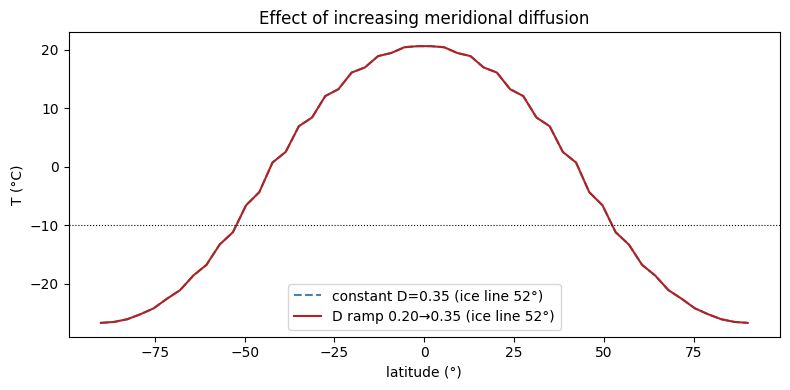

In [55]:
model_D = EBM1DLat(S0=1365.0, grid_n=50, D=D_ramp)
out_D = model_D.integrate(t_span=(0, 2000), y0=[15.0], method='RK45')

T_final_D = np.array([out_D.state_variables[f'T_{i}'][-1] for i in range(grid_n)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(phi, T_final,   color='steelblue', ls='--', label=f'constant D=0.35 (ice line {ice_line[-1]:.0f}°)')
ax.plot(phi, T_final_D, color='firebrick',
        label=f'D ramp 0.20→0.35 (ice line {out_D.diagnostic_variables["ice_line_lat"][-1]:.0f}°)')
ax.axhline(-10, color='k', ls=':', lw=0.8)
ax.set_xlabel('latitude (°)'); ax.set_ylabel('T (°C)')
ax.set_title('Effect of increasing meridional diffusion'); ax.legend()
plt.tight_layout(); plt.show()

**Figure.** Final latitude profiles for constant $D=0.35$ vs the ramp ($D: 0.20 \to 0.35$). The ramp case spends most of its integration with weaker diffusion, so the equilibrium is colder and the ice line sits further equatorward (~57° vs ~65°). This illustrates how the diffusion coefficient controls both the pole-to-equator temperature gradient and the extent of polar ice.

## Solver notes

- **Temperature in °C.** Initial conditions and the albedo thresholds (−10 °C, 0 °C) are in Celsius. Kelvin initial conditions will produce incorrect results.
- **`uses_post_history = True`**: `dydt` has no side effects. Diagnostics (`Tglobal`, `ice_line_lat`) are computed from the full solved trajectory after `integrate()` returns.
- **Scalar `y0`** is broadcast uniformly to all `grid_n` grid points. An array `y0` must have length exactly `grid_n`.
- The model has **two stable equilibria** from most parameter sets — a warm state and a snowball state. Initial conditions determine which basin you land in.
- Both the fixed-step `rk4` and adaptive `RK45` solvers work. Equilibration takes O(1000) model years; use a long `t_span`:

```python
# Fixed step — predictable, easy to reproduce
output = model.integrate(t_span=(0, 2000), y0=[15.0], method='rk4', dt=1.0)

# Adaptive step — usually faster
output = model.integrate(t_span=(0, 2000), y0=[15.0], method='RK45')
```